In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from scipy.optimize import minimize
import time
import math
from dataclasses import dataclass

from IPython.display import display
import pennylane as qml
from pennylane import numpy as qnp

import networkx as nx

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(7)

## Task 1: QAOA Comparison (Standard vs CVaR vs Tilted)

In [4]:
# Code to generate the graph
def make_graph(n, family, seed):
    if family == "regular3":
        graph = nx.random_regular_graph(3, n, seed=seed)
    elif family == "erdos_renyi":
        p = min(0.45, 3.0 / (n - 1))
        graph = nx.gnp_random_graph(n, p, seed=seed)
        while not nx.is_connected(graph):
            seed += 1
            graph = nx.gnp_random_graph(n, p, seed=seed)
    else:
        raise ValueError(f"Unknown graph family: {family}")
    return graph


def basis_states(n):
    return np.array([list(map(int, f"{i:0{n}b}")) for i in range(2**n)], dtype=int)


def cut_values_from_samples(samples, edges):
    samples = np.asarray(samples, dtype=int)
    cuts = np.zeros(samples.shape[0], dtype=int)
    for u, v in edges:
        cuts += (samples[:, u] != samples[:, v]).astype(int)
    return cuts


def exact_cut_data(n, edges):
    basis = basis_states(n)
    cuts = cut_values_from_samples(basis, edges)
    return basis, cuts.astype(float), float(cuts.max())

Define the Hamiltonian

Define the loss functions.

Define the QAOA circuit and optimizer.

## Run the benchmarks

The notebook keeps the main benchmark compact, then adds three targeted ablations to justify scheduling:

- **Main benchmark**: expectation / fixed-QTL / scheduled-QTL over `n = 8, 10, 12` and `p = 1, 2, 3`.
- **Fixed-gamma grid**: one representative setting to test whether any constant gamma dominates.
- **Schedule ablation**: low-to-high, high-to-low, and sigmoid schedules on a harder low-depth setting.
- **Landscape demo**: a small exact `p = 1` case to visualize how changing gamma changes the objective geometry.

The default `FAST_CONFIG` is meant for iteration. Switch to `FULL_CONFIG` if you want paper-ready averages.


In [9]:
curve_df, final_df = run_benchmark(RUN_CONFIG, MAIN_OBJECTIVES, exact=False)
# budget_df = run_budget_tradeoff(RUN_CONFIG, BUDGET_OBJECTIVES)

fig1_df = curve_df[
    (curve_df["graph_family"] == RUN_CONFIG["graph_families"][0])
    & (curve_df["n"] == RUN_CONFIG["curve_n"])
    & (curve_df["objective"].isin(CURVE_OBJECTIVES))
]


Benchmark (sampled): family=erdos_renyi, n=8, p=2, seed=0


In [11]:
finite_summary = (
    final_df.groupby("objective")[["final_mean_ratio", "final_best_ratio", "final_optimal_mass", "success_target", "steps_to_target", "final_loss"]]
    .mean()
    .sort_values(["final_best_ratio", "final_mean_ratio"], ascending=False)
)
display(finite_summary.round(4))

,final_mean_ratio,final_best_ratio,final_optimal_mass,success_target,steps_to_target,final_loss
objective,,,,,,
QTL gamma=2.0,0.7959,1.0,0.2324,1.0,1.0,0.6012
QTL schedule linear,0.7921,1.0,0.2324,1.0,1.0,0.2777
QTL gamma=5.0,0.7903,1.0,0.2334,1.0,1.0,0.2754
Expectation,0.6240,1.0,0.0273,1.0,1.0,2.6553


In [13]:
fig1_df = curve_df[
    (curve_df["graph_family"] == RUN_CONFIG["graph_families"][0])
    & (curve_df["n"] == RUN_CONFIG["curve_n"])
    & (curve_df["objective"].isin(CURVE_OBJECTIVES))
]

In [14]:
def jump_points(x, y):
    x_new = [(x[i] + x[i + 1] + x[i + 2]) / 3 for i in range(0, len(x), 3)]
    y_new = [(y[i] + y[i + 1] + y[i + 2]) / 3 for i in range(0, len(y), 3)]
    return x_new, y_new

# def plot_mean_with_band(ax, df, x_col, y_col, label, color):
#     agg = df.groupby(x_col)[y_col].agg(["mean", "std"]).reset_index()
#     # x, y = jump_points(agg[x_col], agg["mean"])
#     ax.plot(agg[x_col], agg["mean"], label=label, color=color, linewidth=2)
    # ax.plot(x, y, label=label, color=color, linewidth=2)
    # std = agg["std"].fillna(0.0)
    # ax.fill_between(
    #     agg[x_col],
    #     agg["mean"] - std,
    #     agg["mean"] + std,
    #     color=color,
    #     alpha=0.15,
    # )
def plot_mean_with_band(ax, df, x_col, y_col, label, color):
    agg = df.groupby(x_col)[y_col].agg(["mean", "std"]).reset_index()
    # x, y = jump_points(agg[x_col], agg["mean"])
    # ax.plot(x, y, label=label, color=color, linewidth=2)
    ax.plot(agg[x_col], agg["mean"], label=label, color=color, linewidth=2)
    ax.scatter([agg[x_col].iloc[-1]], [agg["mean"].iloc[-1]], color=color, s=28, zorder=3)
    return agg


## Gamma sweep for QTL on 4-qubit Erdos-Renyi Max-Cut

The cells below run a standalone numerical experiment: for each $\gamma \in [0, 20]$, we optimize a depth-$p=2$ QAOA ansatz with quantum tilted loss on 5 connected 4-node Erdos-Renyi graphs, then average the resulting mean cut ratio and plot it in a style inspired by the reference figure.


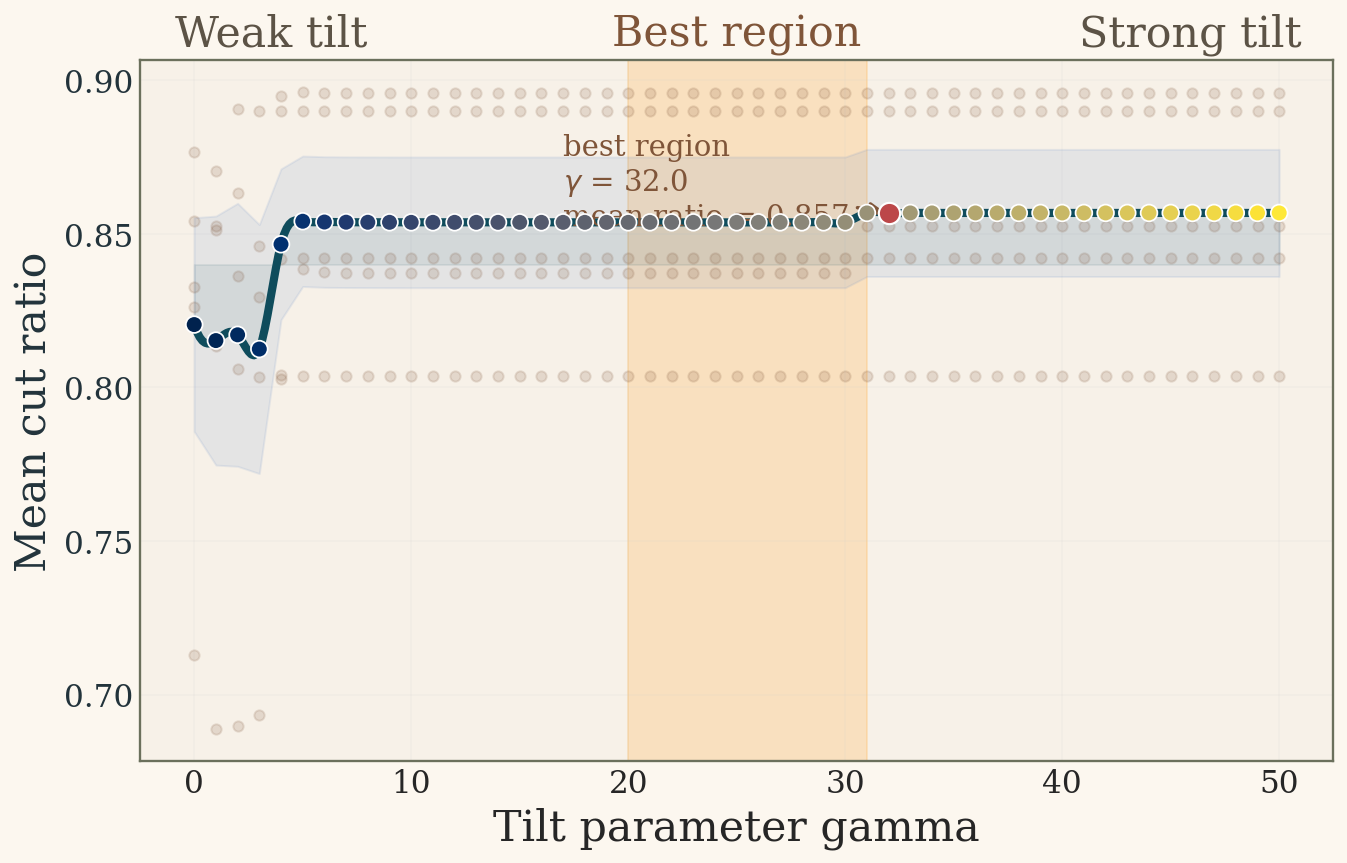

Saved /Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_gamma_mean_cut_ratio.png
Saved /Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_gamma_mean_cut_ratio.pdf


,gamma,mean_cut_ratio,std_cut_ratio
0,0.0,0.8204,0.0633
1,1.0,0.8152,0.0737
2,2.0,0.8171,0.0778
3,3.0,0.8125,0.0737
4,4.0,0.8466,0.0446
5,5.0,0.8541,0.0386
6,6.0,0.8538,0.0386
7,7.0,0.8538,0.0387
8,8.0,0.8537,0.0387
9,9.0,0.8537,0.0387


In [25]:

fig, ax = plt.subplots(figsize=(11.0, 6.5))
fig.patch.set_facecolor("#fcf7ef")
ax.set_facecolor("#f7f1e8")
ax.axvspan(
    max(0.0, best_gamma - best_region_half_width),
    min(20.0, best_gamma + best_region_half_width),
    color="#ffbf69",
    alpha=0.32,
    zorder=0,
)
ax.fill_between(
    gamma_summary_df["gamma"],
    gamma_summary_df["mean_cut_ratio"] - 0.55 * gamma_summary_df["std_cut_ratio"],
    gamma_summary_df["mean_cut_ratio"] + 0.55 * gamma_summary_df["std_cut_ratio"],
    color="#5f88c9",
    alpha=0.12,
    zorder=1,
)
ax.fill_between(x_dense, y_dense, y_min, color="#0f4c5c", alpha=0.08, zorder=1)
ax.scatter(
    gamma_sweep_df["gamma"],
    gamma_sweep_df["mean_cut_ratio"],
    color="#7f5539",
    s=28,
    alpha=0.16,
    zorder=2,
)
ax.plot(x_dense, y_dense, color="#0f4c5c", linewidth=4.2, zorder=3)
ax.scatter(
    gamma_summary_df["gamma"],
    gamma_summary_df["mean_cut_ratio"],
    c=gamma_summary_df["gamma"],
    cmap="cividis",
    s=74,
    edgecolor="white",
    linewidth=0.9,
    zorder=4,
)
ax.scatter([best_gamma], [best_ratio], color="#bc4749", s=120, edgecolor="white", linewidth=1.1, zorder=5)
ax.annotate(
    f"best region\n$\\gamma$ = {best_gamma:.1f}\nmean ratio = {best_ratio:.3f}",
    xy=(best_gamma, best_ratio),
    xytext=(min(17.0, best_gamma + 2.8), min(y_max - 0.01, best_ratio + 0.010)),
    fontsize=15,
    color="#7f5539",
    ha="left",
    va="center",
    arrowprops={"arrowstyle": "-|>", "color": "#7f5539", "lw": 1.8},
)

ax.text(0.11, 1.02, "Weak tilt", transform=ax.transAxes, fontsize=22, ha="center", color="#5c5346")
ax.text(0.50, 1.02, "Best region", transform=ax.transAxes, fontsize=22, ha="center", color="#7f5539")
ax.text(0.88, 1.02, "Strong tilt", transform=ax.transAxes, fontsize=22, ha="center", color="#5c5346")

# ax.set_title("QTL-QAOA gamma sweep", pad=18, color="#22333b")
# ax.text(
#     0.02,
#     0.94,
#     "4-qubit connected Erdos-Renyi graphs, p=2, averaged over 5 graph instances",
#     transform=ax.transAxes,
#     fontsize=15,
#     color="#555555",
# )
ax.set_xlabel("Tilt parameter gamma")
ax.set_ylabel("Mean cut ratio", color="#22333b")
ax.tick_params(axis="y", colors="#22333b")
# ax.set_xlim(0.0, 20.0)
# ax.set_ylim(y_min, y_max)
ax.grid(alpha=0.12)
for spine in ax.spines.values():
    spine.set_color("#6b705c")
    spine.set_linewidth(1.2)

# output_png = "/Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_gamma_mean_cut_ratio.png"
# output_pdf = "/Users/qiuyixian/Desktop/Research/QTL/code/QTL/qtl_gamma_mean_cut_ratio.pdf"
fig.savefig(output_png, bbox_inches="tight", dpi=240)
fig.savefig(output_pdf, bbox_inches="tight")
plt.show()

print(f"Saved {output_png}")
print(f"Saved {output_pdf}")
display(gamma_summary_df.round(4))